In [58]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [2]:
Spotify_limpio = pd.read_csv('Spotify_data_total.csv')

In [3]:
Spotify_limpio.head()

,EDAD,GENERO,ANTIGUEDAD,DISPOSITIVO,SUSCRIPCION,QUIERE_PREMIUM,PREMIUM_PREFERIDO,CONTENIDO_PREFERIDO,GENERO_FAV_MUSICA,FRANJA_HORARIA,...,MOMENTO_MUSICA,DESCUBRIMIENTO,VALORACION_RECOMENDACIONES,FRECUENCIA_POD,GENERO_FAV_POD,FORMATO_PREFERIDO_POD,PREFERENCIA_PRESENTADOR_POD,PREFERENCIA_DURACION_POD,SATISFACCION_POD,CANTIDAD_DISPOSITIVOS
0,20-35,Mujer,Más de 2 años,Altavoz Inteligente,Free,Si,Family Plan-Rs 179/month,Podcast,Melody,Noche,...,Tiempo libre,Listas de reproducción,3,Diariamente,Comedia,Entrevista,Ambos,Ambos,Ok,1
1,12-20,Hombre,Más de 2 años,Ordenador,Free,Si,Individual Plan- Rs 119/ month,Podcast,Rap,Tarde,...,Entrenamiento,Listas de reproducción,2,Varias veces por semana,Comedia,Entrevista,Ambos,No aplicable/Ninguno,Satisfecho,1
2,35-60,Otro,De 6 meses a 1 año,Altavoz Inteligente,Free,Si,Student Plan-Rs 59/month,Podcast,Pop,Noche,...,"Horas de estudio, Mientras viaja",Listas de reproducción,4,Una vez por semana,Deportes,Entrevista,No aplicable/Ninguno,Ambos,Satisfecho,1
3,20-35,Mujer,De 1 año a 2 años,"Smartphone, Altavoz Inteligente",Free,No,No aplicable/Ninguno,Music,Melody,Noche,...,"Horario de oficina, Entrenamiento, Tiempo libre","Recomendaciones, Listas de reproducción",4,Nunca,No aplicable/Ninguno,No aplicable/Ninguno,No aplicable/Ninguno,No aplicable/Ninguno,Ok,2
4,20-35,Mujer,De 1 año a 2 años,Smartphone,Free,No,No aplicable/Ninguno,Music,Melody,Noche,...,Tiempo libre,"Recomendaciones, Listas de reproducción",4,Raramente,Estilo de vida y salud,Relato,Famoso,Ambos,Ok,1


In [4]:
Spotify_limpio.columns

Index(['EDAD', 'GENERO', 'ANTIGUEDAD', 'DISPOSITIVO', 'SUSCRIPCION',
       'QUIERE_PREMIUM', 'PREMIUM_PREFERIDO', 'CONTENIDO_PREFERIDO',
       'GENERO_FAV_MUSICA', 'FRANJA_HORARIA', 'ESTADO_ANIMO', 'MOMENTO_MUSICA',
       'DESCUBRIMIENTO', 'VALORACION_RECOMENDACIONES', 'FRECUENCIA_POD',
       'GENERO_FAV_POD', 'FORMATO_PREFERIDO_POD',
       'PREFERENCIA_PRESENTADOR_POD', 'PREFERENCIA_DURACION_POD',
       'SATISFACCION_POD', 'CANTIDAD_DISPOSITIVOS'],
      dtype='object')

In [5]:
Spotify_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   EDAD                         520 non-null    object
 1   GENERO                       520 non-null    object
 2   ANTIGUEDAD                   520 non-null    object
 3   DISPOSITIVO                  520 non-null    object
 4   SUSCRIPCION                  520 non-null    object
 5   QUIERE_PREMIUM               520 non-null    object
 6   PREMIUM_PREFERIDO            520 non-null    object
 7   CONTENIDO_PREFERIDO          520 non-null    object
 8   GENERO_FAV_MUSICA            520 non-null    object
 9   FRANJA_HORARIA               520 non-null    object
 10  ESTADO_ANIMO                 520 non-null    object
 11  MOMENTO_MUSICA               520 non-null    object
 12  DESCUBRIMIENTO               520 non-null    object
 13  VALORACION_RECOMENDACIONES   520 no

### Codificación de columnas multirrespuesta

In [6]:
multirrespuesta_cols = ["DISPOSITIVO", "MOMENTO_MUSICA", "DESCUBRIMIENTO", "ESTADO_ANIMO", "GENERO_FAV_POD"]

for col in multirrespuesta_cols:
    Spotify_limpio[col] = Spotify_limpio[col].str.split(", ")
    
for col in multirrespuesta_cols:
    dummies = Spotify_limpio[col].str.join('|').str.get_dummies()
    dummies = dummies.add_prefix(col + "_")
    Spotify_limpio = pd.concat([Spotify_limpio, dummies], axis=1)
    Spotify_limpio.drop(columns=[col], inplace=True)

### Codificación de la tabla completa

In [7]:
Spotify_codificado = pd.get_dummies(Spotify_limpio, drop_first=True)

In [8]:
Spotify_codificado.head()

,VALORACION_RECOMENDACIONES,CANTIDAD_DISPOSITIVOS,DISPOSITIVO_Altavoz Inteligente,DISPOSITIVO_Dispositivo Portatil Inteligente,DISPOSITIVO_Ordenador,DISPOSITIVO_Smartphone,MOMENTO_MUSICA_Aleatorio,MOMENTO_MUSICA_Antes de dormir,MOMENTO_MUSICA_Cocinando,MOMENTO_MUSICA_Entrenamiento,...,PREFERENCIA_PRESENTADOR_POD_Desconocido,PREFERENCIA_PRESENTADOR_POD_Famoso,PREFERENCIA_PRESENTADOR_POD_No aplicable/Ninguno,PREFERENCIA_DURACION_POD_Corto,PREFERENCIA_DURACION_POD_Largo,PREFERENCIA_DURACION_POD_No aplicable/Ninguno,SATISFACCION_POD_Muy insatisfecho,SATISFACCION_POD_Muy satisfecho,SATISFACCION_POD_Ok,SATISFACCION_POD_Satisfecho
0,3,1,1,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,2,1,0,0,1,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,True
2,4,1,1,0,0,0,0,0,0,0,...,False,False,True,False,False,False,False,False,False,True
3,4,2,1,0,0,1,0,0,0,1,...,False,False,True,False,False,True,False,False,True,False
4,4,1,0,0,0,1,0,0,0,0,...,False,True,False,False,False,False,False,False,True,False


In [11]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(Spotify_scaled)

Spotify_codificado['CLUSTER'] = clusters

C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [20]:
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster

# Árbol jerárquico con single linkage
Z_single = linkage(Spotify_scaled, method="single", metric="euclidean")

# Etiquetas de 3 clusters (0,1,2)
clusters_single = fcluster(Z_single, t=3, criterion="maxclust") - 1

# Guardar en tu dataframe
Spotify_codificado["CLUSTER_SINGLE"] = clusters_single

# Tamaños
Spotify_codificado["CLUSTER_SINGLE"].value_counts()

CLUSTER_SINGLE
0    518
2      1
1      1
Name: count, dtype: int64

In [19]:
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster

# Z = árbol jerárquico (average linkage)
Z = linkage(Spotify_scaled, method="average", metric="euclidean")

# Sacar 3 clusters (t = 3) y convertir a 0,1,2 (por comodidad)
clusters_avg = fcluster(Z, t=3, criterion="maxclust") - 1

# Guardarlo en tu dataframe
Spotify_codificado["CLUSTER_AVG"] = clusters_avg

# Ver tamaños
Spotify_codificado["CLUSTER_AVG"].value_counts()

CLUSTER_AVG
0    518
2      1
1      1
Name: count, dtype: int64

In [17]:
Y = pdist(Spotify_scaled, metric='euclidean')

for method in ['ward', 'average', 'complete', 'single']:
    Z = linkage(Spotify_scaled, method=method)
    coph_corr, _ = cophenet(Z, Y)
    print(method, round(coph_corr, 4))

ward 0.21
average 0.9736
complete 0.9502
single 0.9646


In [12]:
Spotify_codificado['CLUSTER'].value_counts()

CLUSTER
1    251
0    136
2    133
Name: count, dtype: int64

### Definir X e Y

In [55]:
y = Spotify_codificado["QUIERE_PREMIUM_Si"]

import re
cols_excluir = [c for c in Spotify_codificado.columns
                if re.search(r"^(QUIERE_PREMIUM_|SUSCRIPCION_)", c) or c.startswith("PREMIUM_")]

X = Spotify_codificado.drop(columns=cols_excluir, errors="ignore")


### Train y Test división. Entrenamiento del modelo

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [70]:
pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),  # with_mean=False por si X es sparse
    ("lr", LogisticRegression(max_iter=5000, class_weight="balanced"))
])
pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,False
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


### Evaluación

In [74]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

[[54 29]
 [16 31]]
              precision    recall  f1-score   support

       False       0.77      0.65      0.71        83
        True       0.52      0.66      0.58        47

    accuracy                           0.65       130
   macro avg       0.64      0.66      0.64       130
weighted avg       0.68      0.65      0.66       130

ROC-AUC: 0.7062291720071777


### Variables más influyentes

In [72]:
coef = pd.Series(
    model.coef_[0],
    index=X.columns
)

coef_sorted = coef.sort_values()

print(coef_sorted.tail(10))
print(coef_sorted.head(10))

DESCUBRIMIENTO_Radio                    0.546252
GENERO_FAV_POD_Tecnología               0.548315
MOMENTO_MUSICA_Antes de dormir          0.557584
MOMENTO_MUSICA_Horas de estudio         0.575158
PREFERENCIA_DURACION_POD_Largo          0.669849
FRECUENCIA_POD_Nunca                    0.680009
GENERO_FAV_POD_Finanzas y actualidad    0.682984
SATISFACCION_POD_Muy satisfecho         0.716349
ESTADO_ANIMO_Tristeza                   0.726381
FORMATO_PREFERIDO_POD_Educativo         0.943466
dtype: float64
GENERO_FAV_MUSICA_Kpop                -0.765409
ESTADO_ANIMO_Reuniones Sociales       -0.699484
DISPOSITIVO_Smartphone                -0.626578
ESTADO_ANIMO_Relajación               -0.477203
ANTIGUEDAD_Menos de 6 meses           -0.472996
SATISFACCION_POD_Muy insatisfecho     -0.435674
GENERO_FAV_POD_No aplicable/Ninguno   -0.419680
GENERO_FAV_POD_Novelas                -0.389284
SATISFACCION_POD_Ok                   -0.379406
GENERO_FAV_POD_Deportes               -0.378428
dtype: float64


### Visualización de las variables más importantes

<Axes: >

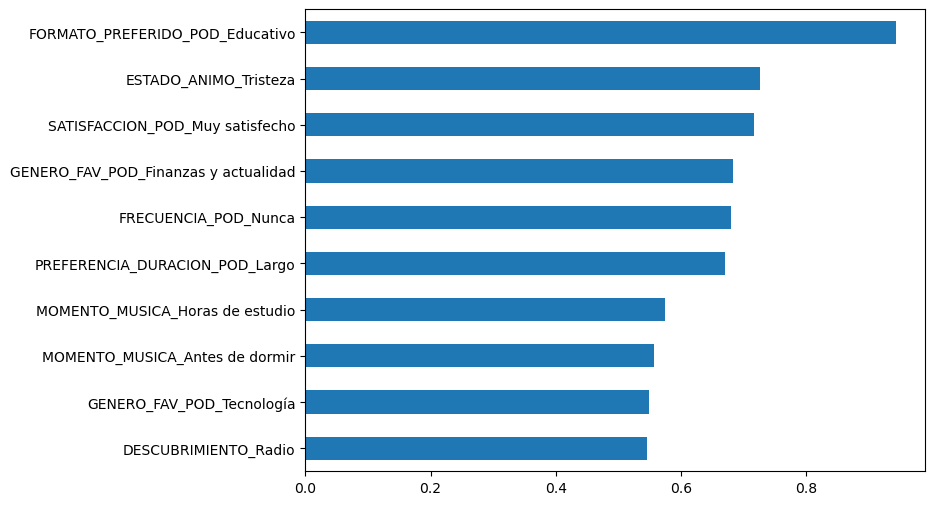

In [73]:
coef_sorted.tail(10).plot.barh(figsize=(8,6))

1) Lo que dicen tus números (en cristiano)
Matriz de confusión
[[54 29]
 [16 31]]

Si tomamos True = quiere premium (1) y False = no quiere premium (0):

TN = 54 → predijo “No” y era “No”

FP = 29 → predijo “Sí” pero era “No”

FN = 16 → predijo “No” pero era “Sí”

TP = 31 → predijo “Sí” y era “Sí”

Esto significa:

El modelo detecta bastantes “Sí” (TP=31), pero también se confunde bastante con falsos positivos (FP=29).

2) Métricas principales
Accuracy = 0.65

En general acierta 65%. No es espectacular, pero es razonable.

Clase “True” (quiere premium)

Precision = 0.52 → cuando predice “Sí”, acierta solo el 52%

Recall = 0.66 → de todos los que realmente quieren premium, detecta el 66%

👉 Esto es importante:
Tu modelo está configurado (por class_weight="balanced") para no perder muchos “Sí”, por eso el recall de la clase positiva es decente.

ROC-AUC = 0.706

Esto es lo más defendible en tu caso:

✅ 0.70 está bien para encuesta pequeña y ruidosa.
Significa que el modelo distingue “sí/no” mejor que azar, pero no de forma perfecta.

3) ¿Está “bien” para tu TFG?

Sí. Para un TFG:

ROC-AUC ~0.70 ✅

F1 (clase positiva) ~0.58 ✅

Interpretabilidad (logística) ✅

Esto ya te permite escribir:

“Se observa capacidad predictiva moderada debido a la homogeneidad/sesgo de la muestra.”